# Assignment 3: Numerical Analysis for PDE's (WI3730TU)
### Numerical Solution of the Two-Dimensional Poisson Equation using Finite-Difference and Finite-Volume Methods

**Boundary-Value Problem Details:**
$$
-\nabla\cdot(k\nabla u) = f, \quad (x,y) \in \Omega = (0,10)\times(0,5)
$$
$$
u(x,y) = 0, \quad (x,y) \in \partial\Omega
$$
$$
f(x,y) = \sum_{i=1}^{9}\sum_{j=1}^{4}e^{-\alpha(x-i)^2-\alpha(y-j)^2}, \quad \alpha = 40
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as la
%matplotlib inline

# Domain parameters
LeftX, RightX = 0.0, 10.0
LeftY, RightY = 0.0, 5.0
Lx = RightX - LeftX
Ly = RightY - LeftY

## 📐 Section 1: Explicit Derivations & Discrete Formulations for 2D FDM

### Question 1.1: $\mathcal{O}(h^2)$ Finite-Difference Approximation (1 p)
For Questions 1.1--1.3, we consider the constant-coefficient case

$$
k(x,y)\equiv 1,
\qquad (x,y)\in\overline{\Omega}.
$$

The original diffusion equation therefore reduces to the Poisson equation

$$
-\nabla\cdot\left(k\nabla u\right)
=
-\Delta u
=
f
\qquad \text{in }
\Omega=(0,L_x)\times(0,L_y),
$$

subject to the homogeneous Dirichlet boundary condition

$$
u=0
\qquad \text{on }\partial\Omega.
$$

We discretize the rectangular domain using a uniform Cartesian grid with possibly different spacings in the two coordinate directions,

$$
x_i=i h_x,
\qquad
i=0,\ldots,N_x,
\qquad
h_x=\frac{L_x}{N_x},
$$

and

$$
y_j=j h_y,
\qquad
j=0,\ldots,N_y,
\qquad
h_y=\frac{L_y}{N_y}.
$$

The mesh is therefore uniform in each coordinate direction, but not necessarily doubly uniform, since in general $h_x\neq h_y.$ At an interior grid point

$$
(x_i,y_j),
\qquad
i=1,\ldots,N_x-1,
\qquad
j=1,\ldots,N_y-1,
$$

the negative Laplacian is $-\Delta u=-u_{xx}-u_{yy}.$ Both second derivatives are approximated using second-order central finite differences. At an interior point $(x_i,y_j)$, Taylor expansion in the $x$-direction gives 
 
$$ 
u_{i+1,j} 
= 
u_{i,j} 
+h_xu_x 
+\frac{h_x^2}{2}u_{xx} 
+\frac{h_x^3}{6}u_{xxx} 
+\frac{h_x^4}{24}u_{xxxx} 
+\frac{h_x^5}{120}u_{xxxxx}
+\mathcal O(h_x^6), 
$$ 
 
and 
 
$$ 
u_{i-1,j} 
= 
u_{i,j} 
-h_xu_x 
+\frac{h_x^2}{2}u_{xx} 
-\frac{h_x^3}{6}u_{xxx} 
+\frac{h_x^4}{24}u_{xxxx} 
-\frac{h_x^5}{120}u_{xxxxx}
+\mathcal O(h_x^6), 
$$ 
 
where all derivatives are evaluated at $(x_i,y_j)$. Adding the two expressions eliminates the odd derivatives, 
 
$$ 
u_{i+1,j}+u_{i-1,j} 
= 
2u_{i,j} 
+h_x^2u_{xx} 
+\frac{h_x^4}{12}u_{xxxx} 
+\mathcal O(h_x^6). 
$$ 
 
Therefore, 
 
$$ 
u_{xx}(x_i,y_j) 
= 
\frac{u_{i-1,j}-2u_{i,j}+u_{i+1,j}}{h_x^2} 
-\frac{h_x^2}{12}u_{xxxx}(x_i,y_j) 
+\mathcal O(h_x^4). 
$$ 
 
Hence the central-difference approximation has truncation error $\mathcal O(h_x^2)$: 
 
$$ 
u_{xx}(x_i,y_j) 
= 
\frac{u_{i-1,j}-2u_{i,j}+u_{i+1,j}}{h_x^2} 
+\mathcal O(h_x^2). 
$$ 
 
Applying exactly the same argument in the $y$-direction gives 
 
$$ 
u_{yy}(x_i,y_j) 
= 
\frac{u_{i,j-1}-2u_{i,j}+u_{i,j+1}}{h_y^2} 
+\mathcal O(h_y^2). 
$$ 
 
Substituting both approximations into $-\Delta u=f$ gives 
 
$$ 
\frac{2u_{i,j}-u_{i-1,j}-u_{i+1,j}}{h_x^2} 
+ 
\frac{2u_{i,j}-u_{i,j-1}-u_{i,j+1}}{h_y^2} 
= 
f_{i,j} 
$$ 
 
for $i=1,\ldots,N_x-1$ and $j=1,\ldots,N_y-1$, where $f_{i,j}=f(x_i,y_j)$. Equivalently, 
 
$$ 
\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{i,j} 
-\frac{u_{i-1,j}+u_{i+1,j}}{h_x^2} 
-\frac{u_{i,j-1}+u_{i,j+1}}{h_y^2} 
= 
f_{i,j}. 
$$ 
 
The local truncation error of the two-dimensional approximation is $\mathcal O(h_x^2+h_y^2),$ so the finite-difference approximation is second-order accurate in space. 


### Question 1.2: Explicit Discrete Equations on a $4 \times 4$ Mesh (2 p)
Given $N_x = 4, N_y = 4 \implies h_x = \frac{10}{4} = 2.5$ and $h_y = \frac{5}{4} = 1.25$. With homogeneous Dirichlet boundary conditions ($u = 0$ on $\partial\Omega$), the boundary unknowns are eliminated, leaving 9 inner unknowns ordered lexicographically:
$$
\mathbf{u} = [u_{1,1}, u_{2,1}, u_{3,1}, u_{1,2}, u_{2,2}, u_{3,2}, u_{1,3}, u_{2,3}, u_{3,3}]^T
$$

The resulting algebraic equations at each interior point evaluate to:

The finite-difference equations at the nine interior nodes are

$$
\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{1,1}
-\frac{1}{h_x^2}u_{2,1}
-\frac{1}{h_y^2}u_{1,2}
=f_{1,1},
$$

$$
-\frac{1}{h_x^2}u_{1,1}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{2,1}
-\frac{1}{h_x^2}u_{3,1}
-\frac{1}{h_y^2}u_{2,2}
=f_{2,1},
$$

$$
-\frac{1}{h_x^2}u_{2,1}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{3,1}
-\frac{1}{h_y^2}u_{3,2}
=f_{3,1},
$$

$$
-\frac{1}{h_y^2}u_{1,1}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{1,2}
-\frac{1}{h_x^2}u_{2,2}
-\frac{1}{h_y^2}u_{1,3}
=f_{1,2},
$$

$$
-\frac{1}{h_y^2}u_{2,1}
-\frac{1}{h_x^2}u_{1,2}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{2,2}
-\frac{1}{h_x^2}u_{3,2}
-\frac{1}{h_y^2}u_{2,3}
=f_{2,2},
$$

$$
-\frac{1}{h_y^2}u_{3,1}
-\frac{1}{h_x^2}u_{2,2}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{3,2}
-\frac{1}{h_y^2}u_{3,3}
=f_{3,2},
$$

$$
-\frac{1}{h_y^2}u_{1,2}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{1,3}
-\frac{1}{h_x^2}u_{2,3}
=f_{1,3},
$$

$$
-\frac{1}{h_y^2}u_{2,2}
-\frac{1}{h_x^2}u_{1,3}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{2,3}
-\frac{1}{h_x^2}u_{3,3}
=f_{2,3},
$$

$$
-\frac{1}{h_y^2}u_{3,2}
-\frac{1}{h_x^2}u_{2,3}
+\left(\frac{2}{h_x^2}+\frac{2}{h_y^2}\right)u_{3,3}
=f_{3,3}.
$$




Substituting the step coefficients:
$$
\frac{1}{h_x^2} = \frac{1}{2.5^2} = 0.16, \quad \frac{1}{h_y^2} = \frac{1}{1.25^2} = 0.64, \quad \frac{2}{h_x^2} + \frac{2}{h_y^2} = 1.6
$$

The system matrix is
$$
A=
\begin{bmatrix}
1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0 & 0 \\
-0.16 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0 \\
0 & -0.16 & 1.6 & 0 & 0 & -0.64 & 0 & 0 & 0 \\
-0.64 & 0 & 0 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0 \\
0 & -0.64 & 0 & -0.16 & 1.6 & -0.16 & 0 & -0.64 & 0 \\
0 & 0 & -0.64 & 0 & -0.16 & 1.6 & 0 & 0 & -0.64 \\
0 & 0 & 0 & -0.64 & 0 & 0 & 1.6 & -0.16 & 0 \\
0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6 & -0.16 \\
0 & 0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6
\end{bmatrix}.
$$



### Question 1.3: Kronecker Product Proof ($A = I_y \otimes L_{xx} + L_{yy} \otimes I_x$) (4 p)
Under lexicographic ordering, the 2D stencil can be decoupled into directional 1D operations. The unknowns are ordered such that the $x$-index varies first,

$$
\mathbf{u}
=
[u_{1,1},u_{2,1},u_{3,1},
u_{1,2},u_{2,2},u_{3,2},
u_{1,3},u_{2,3},u_{3,3}]^T.
$$

Therefore, the $x$-direction operator acts separately on each horizontal row, while the $y$-direction operator connects corresponding nodes in adjacent horizontal rows.

For a 1D problem with $N=4$, the negative 1D Laplacians $L_{xx}$ and $L_{yy}$ are generated from $D_x^TD_x$ and $D_y^TD_y$ as follows.

$$  
I_x =   
\begin{bmatrix}  
1&0&0\\ 
0&1&0\\ 
0&0&1 
\end{bmatrix}  
,\;\;\;  
I_y =   
\begin{bmatrix}  
1&0&0\\ 
0&1&0\\ 
0&0&1 
\end{bmatrix}  
$$  
  
$$  
D_x=\frac{1}{h_x}  
\begin{bmatrix}  
1&0&0\\ 
-1&1&0\\ 
0&-1&1\\ 
0&0&-1 
\end{bmatrix}  
,\;\;\;  
D_y=\frac{1}{h_y}  
\begin{bmatrix}  
1&0&0\\ 
-1&1&0\\ 
0&-1&1\\ 
0&0&-1 
\end{bmatrix}  
$$  
  
$$  
L_{xx}=D_x^{T}D_x=  
\frac{1}{h_x^{2}}  
\begin{bmatrix}  
1&-1&0&0\\ 
0&1&-1&0\\ 
0&0&1&-1 
\end{bmatrix}  
\begin{bmatrix}  
1&0&0\\ 
-1&1&0\\ 
0&-1&1\\ 
0&0&-1 
\end{bmatrix}  
=  
\frac{1}{h_x^{2}}  
\begin{bmatrix}  
2&-1&0\\ 
-1&2&-1\\ 
0&-1&2 
\end{bmatrix}  
=  
\begin{bmatrix}  
0.32&-0.16&0\\ 
-0.16&0.32&-0.16\\ 
0&-0.16&0.32 
\end{bmatrix}  
$$  
  
$$  
L_{yy}=D_y^{T}D_y=  
\frac{1}{h_y^{2}}  
\begin{bmatrix}  
1&-1&0&0\\ 
0&1&-1&0\\ 
0&0&1&-1 
\end{bmatrix}  
\begin{bmatrix}  
1&0&0\\ 
-1&1&0\\ 
0&-1&1\\ 
0&0&-1 
\end{bmatrix}  
=  
\frac{1}{h_y^{2}}  
\begin{bmatrix}  
2&-1&0\\ 
-1&2&-1\\ 
0&-1&2 
\end{bmatrix}  
=  
\begin{bmatrix}  
1.28&-0.64&0\\ 
-0.64&1.28&-0.64\\ 
0&-0.64&1.28 
\end{bmatrix}  
$$

The Kronecker product $I_y\otimes L_{xx}$ repeats the $x$-direction operator along the diagonal, so that $L_{xx}$ is applied independently to each horizontal row of unknowns:

$$  
I_y\otimes L_{xx} =   
\begin{bmatrix}  
1&0&0\\ 
0&1&0\\ 
0&0&1 
\end{bmatrix}  
\otimes  
\begin{bmatrix}  
0.32&-0.16&0\\ 
-0.16&0.32&-0.16\\ 
0&-0.16&0.32 
\end{bmatrix}.
$$

Using the definition of the Kronecker product,

$$
I_y\otimes L_{xx}
=
\begin{bmatrix}
1L_{xx} & 0L_{xx} & 0L_{xx}\\
0L_{xx} & 1L_{xx} & 0L_{xx}\\
0L_{xx} & 0L_{xx} & 1L_{xx}
\end{bmatrix}.
$$
  
Therefore,

$$  
I_y\otimes L_{xx}
=  
\begin{bmatrix}  
0.32&-0.16&0&0&0&0&0&0&0\\ 
-0.16&0.32&-0.16&0&0&0&0&0&0\\ 
0&-0.16&0.32&0&0&0&0&0&0\\ 
0&0&0&0.32&-0.16&0&0&0&0\\ 
0&0&0&-0.16&0.32&-0.16&0&0&0\\ 
0&0&0&0&-0.16&0.32&0&0&0\\ 
0&0&0&0&0&0&0.32&-0.16&0\\ 
0&0&0&0&0&0&-0.16&0.32&-0.16\\ 
0&0&0&0&0&0&0&-0.16&0.32 
\end{bmatrix}.  
$$

Similarly, $L_{yy}\otimes I_x$ applies the $y$-direction coupling between corresponding $x$-positions in adjacent horizontal rows:

$$  
L_{yy}\otimes I_x =   
\begin{bmatrix}  
1.28&-0.64&0\\ 
-0.64&1.28&-0.64\\ 
0&-0.64&1.28 
\end{bmatrix}  
\otimes  
\begin{bmatrix}  
1&0&0\\ 
0&1&0\\ 
0&0&1 
\end{bmatrix}.  
$$

Using the block form of the Kronecker product,

$$
L_{yy}\otimes I_x
=
\begin{bmatrix}
1.28I_x & -0.64I_x & 0I_x\\
-0.64I_x & 1.28I_x & -0.64I_x\\
0I_x & -0.64I_x & 1.28I_x
\end{bmatrix}.
$$
  
Hence,

$$  
L_{yy}\otimes I_x
=  
\begin{bmatrix}  
1.28&0&0&-0.64&0&0&0&0&0\\ 
0&1.28&0&0&-0.64&0&0&0&0\\ 
0&0&1.28&0&0&-0.64&0&0&0\\ 
-0.64&0&0&1.28&0&0&-0.64&0&0\\ 
0&-0.64&0&0&1.28&0&0&-0.64&0\\ 
0&0&-0.64&0&0&1.28&0&0&-0.64\\ 
0&0&0&-0.64&0&0&1.28&0&0\\ 
0&0&0&0&-0.64&0&0&1.28&0\\ 
0&0&0&0&0&-0.64&0&0&1.28 
\end{bmatrix}.  
$$

The complete two-dimensional negative Laplacian is obtained by adding the contributions from both coordinate directions,

$$
A
=
I_y\otimes L_{xx}
+
L_{yy}\otimes I_x.
$$

Thus,

$$
A=
\begin{bmatrix}  
0.32&-0.16&0&0&0&0&0&0&0\\ 
-0.16&0.32&-0.16&0&0&0&0&0&0\\ 
0&-0.16&0.32&0&0&0&0&0&0\\ 
0&0&0&0.32&-0.16&0&0&0&0\\ 
0&0&0&-0.16&0.32&-0.16&0&0&0\\ 
0&0&0&0&-0.16&0.32&0&0&0\\ 
0&0&0&0&0&0&0.32&-0.16&0\\ 
0&0&0&0&0&0&-0.16&0.32&-0.16\\ 
0&0&0&0&0&0&0&-0.16&0.32 
\end{bmatrix}
+
\begin{bmatrix}  
1.28&0&0&-0.64&0&0&0&0&0\\ 
0&1.28&0&0&-0.64&0&0&0&0\\ 
0&0&1.28&0&0&-0.64&0&0&0\\ 
-0.64&0&0&1.28&0&0&-0.64&0&0\\ 
0&-0.64&0&0&1.28&0&0&-0.64&0\\ 
0&0&-0.64&0&0&1.28&0&0&-0.64\\ 
0&0&0&-0.64&0&0&1.28&0&0\\ 
0&0&0&0&-0.64&0&0&1.28&0\\ 
0&0&0&0&0&-0.64&0&0&1.28 
\end{bmatrix},
$$

which gives

$$
A=
\begin{bmatrix}
1.60&-0.16&0&-0.64&0&0&0&0&0\\
-0.16&1.60&-0.16&0&-0.64&0&0&0&0\\
0&-0.16&1.60&0&0&-0.64&0&0&0\\
-0.64&0&0&1.60&-0.16&0&-0.64&0&0\\
0&-0.64&0&-0.16&1.60&-0.16&0&-0.64&0\\
0&0&-0.64&0&-0.16&1.60&0&0&-0.64\\
0&0&0&-0.64&0&0&1.60&-0.16&0\\
0&0&0&0&-0.64&0&-0.16&1.60&-0.16\\
0&0&0&0&0&-0.64&0&-0.16&1.60
\end{bmatrix}.
$$

Thus, the Kronecker-sum representation produces exactly the five-point finite-difference stencil under the chosen lexicographic ordering. For $N_x=N_y=4$, this yields the same $9\times9$ matrix $A$ written out explicitly in Question 1.2.

## 📐 Section 2: Discrete Formulation for 2D FVM (3 p)

For a uniform grid with grid steps $h_x$ and $h_y$ the inner point vertex-centered FV equation averaged over the elementary cell is:

Consider the steady diffusion problem on a rectangular domain $\Omega\subset\mathbb{R}^2$,

$$
-\nabla\cdot\left(k\nabla u\right)=f
\qquad \text{in } \Omega,
$$

Subject to

$$
u=0
\qquad \text{on }\partial\Omega.
$$

where $u=u(x,y)$ is the unknown scalar field, $k=k(x,y)>0$ is the diffusion coefficient, and $f=f(x,y)$ is the source term. Assume that $u$, $k$, and $f$ are sufficiently smooth. Let the domain be discretized by a uniform Cartesian grid,

$$
x_i=i h_x,
\qquad
y_j=j h_y.
$$

For an interior vertex $(x_i,y_j)$, define the vertex-centred control volume

$$
V_{i,j}
=
\left[x_i-\frac{h_x}{2},x_i+\frac{h_x}{2}\right]
\times
\left[y_j-\frac{h_y}{2},y_j+\frac{h_y}{2}\right],
$$

with area

$$
|V_{i,j}|=h_xh_y.
$$

The finite-volume method starts by integrating the differential equation over the complete two-dimensional control volume $V_{i,j}$:

$$
-\iint_{V_{i,j}}
\nabla\cdot\left(k\nabla u\right)\,\mathrm dA
=
\iint_{V_{i,j}} f\,\mathrm dA.
$$

Applying the two-dimensional divergence theorem converts the area integral of the divergence into a line integral over the boundary $\partial V_{i,j}$ of the control volume:

$$
-\oint_{\partial V_{i,j}}
k\nabla u\cdot\mathbf n\,\mathrm ds
=
\iint_{V_{i,j}} f\,\mathrm dA,
$$

where $\mathbf n$ denotes the outward-pointing unit normal vector along the boundary of the control volume. For the west, east, south, and north faces,

$$
\mathbf n_W=(-1,0),
\qquad
\mathbf n_E=(1,0),
\qquad
\mathbf n_S=(0,-1),
\qquad
\mathbf n_N=(0,1).
$$

Hence,

$$
\nabla u\cdot\mathbf n_W=-u_x,
\qquad
\nabla u\cdot\mathbf n_E=u_x,
\qquad
\nabla u\cdot\mathbf n_S=-u_y,
\qquad
\nabla u\cdot\mathbf n_N=u_y.
$$

Approximating each face integral by the midpoint value of the corresponding flux gives

$$
h_y
\left[
k_{i-\frac12,j}u_x\big|_{i-\frac12,j}
-
k_{i+\frac12,j}u_x\big|_{i+\frac12,j}
\right]
+
h_x
\left[
k_{i,j-\frac12}u_y\big|_{i,j-\frac12}
-
k_{i,j+\frac12}u_y\big|_{i,j+\frac12}
\right]
=
\iint_{V_{i,j}}f\,\mathrm dA.
$$

The derivatives at the face midpoints are approximated using the two neighbouring vertices:

$$
u_x\big|_{i-\frac12,j}
=
\frac{u_{i,j}-u_{i-1,j}}{h_x}
+\mathcal O(h_x^2),
\qquad
u_x\big|_{i+\frac12,j}
=
\frac{u_{i+1,j}-u_{i,j}}{h_x}
+\mathcal O(h_x^2),
$$

and

$$
u_y\big|_{i,j-\frac12}
=
\frac{u_{i,j}-u_{i,j-1}}{h_y}
+\mathcal O(h_y^2),
\qquad
u_y\big|_{i,j+\frac12}
=
\frac{u_{i,j+1}-u_{i,j}}{h_y}
+\mathcal O(h_y^2).
$$

The source integral is approximated by the two-dimensional midpoint rule:

$$
\iint_{V_{i,j}}f\,\mathrm dA
=
f_{i,j}h_xh_y
+\mathcal O(h_x^3h_y+h_xh_y^3).
$$

Substituting the face-flux and source approximations gives

$$
h_y
\left[
k_{i-\frac12,j}
\frac{u_{i,j}-u_{i-1,j}}{h_x}
-
k_{i+\frac12,j}
\frac{u_{i+1,j}-u_{i,j}}{h_x}
\right]
+
h_x
\left[
k_{i,j-\frac12}
\frac{u_{i,j}-u_{i,j-1}}{h_y}
-
k_{i,j+\frac12}
\frac{u_{i,j+1}-u_{i,j}}{h_y}
\right]
=
f_{i,j}h_xh_y.
$$

Dividing by the control-volume area $h_xh_y$ yields the finite-volume equation at the interior vertex $(x_i,y_j)$:

$$
k_{i-\frac12,j}
\frac{u_{i,j}-u_{i-1,j}}{h_x^2}
-
k_{i+\frac12,j}
\frac{u_{i+1,j}-u_{i,j}}{h_x^2}
+
k_{i,j-\frac12}
\frac{u_{i,j}-u_{i,j-1}}{h_y^2}
-
k_{i,j+\frac12}
\frac{u_{i,j+1}-u_{i,j}}{h_y^2}
=
f_{i,j}.
$$

Collecting the coefficients of the nodal values gives

$$
\left[
\frac{k_{i-\frac12,j}+k_{i+\frac12,j}}{h_x^2}
+
\frac{k_{i,j-\frac12}+k_{i,j+\frac12}}{h_y^2}
\right]u_{i,j}
-
\frac{k_{i-\frac12,j}}{h_x^2}u_{i-1,j}
-
\frac{k_{i+\frac12,j}}{h_x^2}u_{i+1,j}
-
\frac{k_{i,j-\frac12}}{h_y^2}u_{i,j-1}
-
\frac{k_{i,j+\frac12}}{h_y^2}u_{i,j+1}
=
f_{i,j}.
$$

Here $k_{i\pm\frac12,j}$ and $k_{i,j\pm\frac12}$ denote the diffusion coefficient evaluated at the four control-volume face midpoints. For a uniform grid and sufficiently smooth $u$, $k$, and $f$, the interior discretization is second-order accurate,

$$
\mathcal O(h_x^2+h_y^2).
$$

For constant $k=1$, the expression reduces to the standard five-point finite-volume discretization of the negative Laplacian.

For $N_x=4$ and $N_y=4$ the indices of the inner points will have the following ranges: $i=1,2,3$, $j=1,2,3$.


## 📊 Section 3: Coding System Assembly Functions

### Question 3.1: Complete the code to assemble the sparse matrices $D_{x}$ or $D_{y}$ and the complete FDM Laplacian using the Kronecker product formula (4 p)

In [3]:
def Diff1(N):
    diagonals = [np.ones(N-1), -np.ones(N-1)]
    locations = [0, -1]
    return sp.diags(diagonals, locations, shape=(N, N-1))

def FDLaplacian2D(Nx, Ny, dx, dy):
    Dx = Diff1(Nx) / dx
    Lxx = Dx.T @ Dx
    Dy = Diff1(Ny) / dy
    Lyy = Dy.T @ Dy
    Ix = sp.eye(Nx-1)
    Iy = sp.eye(Ny-1)
    return sp.kron(Iy, Lxx) + sp.kron(Lyy, Ix)

In [4]:
# you can test your assembly function as follows
Nx = 4
Ny = 4
dx = Lx/Nx
dy = Ly/Ny
print(FDLaplacian2D(Nx,Ny,dx,dy).todense())

[[ 1.6  -0.16  0.   -0.64  0.    0.    0.    0.    0.  ]
 [-0.16  1.6  -0.16  0.   -0.64  0.    0.    0.    0.  ]
 [ 0.   -0.16  1.6   0.    0.   -0.64  0.    0.    0.  ]
 [-0.64  0.    0.    1.6  -0.16  0.   -0.64  0.    0.  ]
 [ 0.   -0.64  0.   -0.16  1.6  -0.16  0.   -0.64  0.  ]
 [ 0.    0.   -0.64  0.   -0.16  1.6   0.    0.   -0.64]
 [ 0.    0.    0.   -0.64  0.    0.    1.6  -0.16  0.  ]
 [ 0.    0.    0.    0.   -0.64  0.   -0.16  1.6  -0.16]
 [ 0.    0.    0.    0.    0.   -0.64  0.   -0.16  1.6 ]]


### Question 3.2: Complete the code to assemble the sparse matrix of the FVM Laplacian (6 p)

In [5]:
def sourcefunc(x, y):
    Nsx = int(Lx) - 1
    Nsy = int(Ly) - 1
    a = 40
    F = 0.0
    for ii in range(Nsx):
        for jj in range(Nsy):
            F = F + np.exp(-a*(x-(ii+1))**2 - a*(y-(jj+1))**2)
    return F

def coeffK1(x, y):
    return np.ones(np.shape(x))

def coeffK2(x, y):
    return 1.0 + 0.1*(x + y + x*y)

In [ ]:
def create2DLFVM(Lx, Ly, Nx, Ny, coeffFun):
    dx, dy = Lx/Nx, Ly/Ny
    n_cells = (Nx-1)*(Ny-1)
    d0 = np.zeros(n_cells)
    d1plus = np.zeros(n_cells-1)
    d1minus = np.zeros(n_cells-1)
    d2plus = np.zeros(n_cells-(Nx-1))
    d2minus = np.zeros(n_cells-(Nx-1))
    
    n0 = 0  # this is the index of the current cell, which will be incremented in the loop below
    for jj in range(Ny-1):
        yj = dy + jj*dy
        for ii in range(Nx-1):
            xi = dx + ii*dx
            kW = coeffFun(xi-dx/2, yj) #This is the coefficient at the west face
            kE = coeffFun(xi+dx/2, yj) #This is the coefficient at the east face
            kS = coeffFun(xi, yj-dy/2) #This is the coefficient at the south face
            kN = coeffFun(xi, yj+dy/2) #This is the coefficient at the north face
            #Main Diagonal
            d0[n0] = ((kW + kE) / dx**2
                      + (kS + kN) / dy**2)
            #West Neighbor
            if ii > 0:   # This condition avoids adding a west-neighbour unknown for u_11, u_12, u_13,
                         # because these nodes are adjacent to the left Dirichlet boundary, where u_0j = 0.
                d1minus[n0-1] = -kW / dx**2   
            if ii < Nx-2:   # This condition avoids adding an east-neighbour unknown for u_31, u_32, u_33,
                            # since their east neighbour lies on the prescribed right boundary u_Nx,j = 0.
                d1plus[n0] = -kE / dx**2                
            #South Neighbor   
            if jj > 0:   # This condition avoids adding a south-neighbour unknown for u_11, u_21, u_31,
                        # since their south neighbour lies on the prescribed bottom boundary u_i,0 = 0.
                d2minus[n0-(Nx-1)] = -kS / dy**2  

            #North Neighbor  # This condition avoids adding a north-neighbour unknown for u_13, u_23, u_33,
                             # since their north neighbour lies on the prescribed top boundary u_i,Ny = 0.
            if jj < Ny-2:
                d2plus[n0] = -kN / dy**2  

            n0 += 1
            
    return sp.diags([d2minus, d1minus, d0, d1plus, d2plus], [-(Nx-1), -1, 0, 1, (Nx-1)], shape=(n_cells, n_cells), format='csc')

## 📊 Section 4: Tests, Simulations, Visualizations

### Question 4.1: Assemble, print, and visualize FDM system matrix on a small grid (1 p)

Test FDM matrix A =
 [[ 1.6  -0.16  0.   -0.64  0.    0.    0.    0.    0.  ]
 [-0.16  1.6  -0.16  0.   -0.64  0.    0.    0.    0.  ]
 [ 0.   -0.16  1.6   0.    0.   -0.64  0.    0.    0.  ]
 [-0.64  0.    0.    1.6  -0.16  0.   -0.64  0.    0.  ]
 [ 0.   -0.64  0.   -0.16  1.6  -0.16  0.   -0.64  0.  ]
 [ 0.    0.   -0.64  0.   -0.16  1.6   0.    0.   -0.64]
 [ 0.    0.    0.   -0.64  0.    0.    1.6  -0.16  0.  ]
 [ 0.    0.    0.    0.   -0.64  0.   -0.16  1.6  -0.16]
 [ 0.    0.    0.    0.    0.   -0.64  0.   -0.16  1.6 ]]


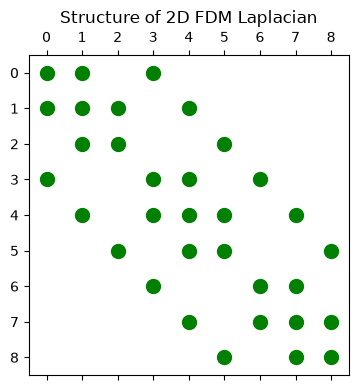

In [ ]:
Nx, Ny = 4, 4
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]
A_fdm_small = FDLaplacian2D(Nx, Ny, dx, dy)
print('Test FDM matrix A =\n',A_fdm_small.todense())

plt.figure(figsize=(5, 4))
plt.spy(A_fdm_small, marker='o', color='green')
plt.title('Structure of 2D FDM Laplacian')
plt.tight_layout()
plt.show()

### Question 4.2: Assemble, print, and test the symmetry of the FVM system matrix on a small grid (1 p)

In [9]:
Nx, Ny = 4, 4
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]
A_fvm_small = create2DLFVM(Lx, Ly, Nx, Ny, coeffK2)
print('Test FVM matrix A =\n',A_fvm_small.todense())
print(
    'Symmetry error =',
    np.linalg.norm((A_fvm_small - A_fvm_small.T).todense())
)

Test FVM matrix A =
 [[ 2.7   -0.315  0.    -1.22   0.     0.     0.     0.     0.   ]
 [-0.315  3.6   -0.405  0.    -1.68   0.     0.     0.     0.   ]
 [ 0.    -0.405  4.5    0.     0.    -2.14   0.     0.     0.   ]
 [-1.22   0.     0.     3.4   -0.41   0.    -1.5    0.     0.   ]
 [ 0.    -1.68   0.    -0.41   4.8   -0.55   0.    -2.16   0.   ]
 [ 0.     0.    -2.14   0.    -0.55   6.2    0.     0.    -2.82 ]
 [ 0.     0.     0.    -1.5    0.     0.     4.1   -0.505  0.   ]
 [ 0.     0.     0.     0.    -2.16   0.    -0.505  6.    -0.695]
 [ 0.     0.     0.     0.     0.    -2.82   0.    -0.695  7.9  ]]
Symmetry error = 0.0


### Question 4.3 Assemble and compute FDM and FVM solutions on a finer grid (3 p)

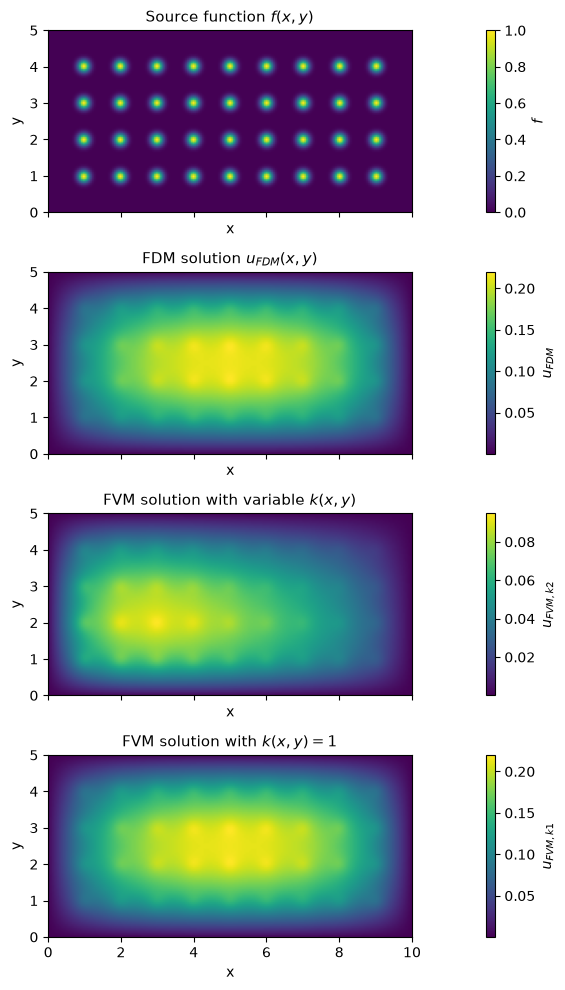

In [19]:
Nx, Ny = 200, 100 
dx, dy = Lx/Nx, Ly/Ny 

x, y = np.mgrid[
    dx:Lx-dx:(Nx-1)*1j,
    dy:Ly-dy:(Ny-1)*1j
] 

f = sourcefunc(x, y) 


# Assemble FDM matrix and solve
A_fdm = FDLaplacian2D(Nx, Ny, dx, dy) 
u_fdm = la.spsolve(A_fdm, f.flatten(order='F')) 


# Assemble FVM matrix with coeffK2 and solve
A_fvm_k2 = create2DLFVM(Lx, Ly, Nx, Ny, coeffK2) 
u_fvm_k2 = la.spsolve(A_fvm_k2, f.flatten(order='F')) 


# Assemble FVM matrix with coeffK1 and solve
A_fvm_k1 = create2DLFVM(Lx, Ly, Nx, Ny, coeffK1) 
u_fvm_k1 = la.spsolve(A_fvm_k1, f.flatten(order='F')) 


# Reshape back to 2D
u_fdm = u_fdm.reshape((Nx-1, Ny-1), order='F') 
u_fvm_k2 = u_fvm_k2.reshape((Nx-1, Ny-1), order='F') 
u_fvm_k1 = u_fvm_k1.reshape((Nx-1, Ny-1), order='F') 


# Visualizations as 2D images
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True) 


# Source function
im0 = axes[0].imshow(
    f.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[0].set_title('Source function $f(x,y)$', fontsize=11) 
fig.colorbar(im0, ax=axes[0], label='$f$') 
axes[0].set_xlabel('x') 
axes[0].set_ylabel('y') 


# FDM solution
im1 = axes[1].imshow(
    u_fdm.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[1].set_title('FDM solution $u_{FDM}(x,y)$', fontsize=11) 
fig.colorbar(im1, ax=axes[1], label='$u_{FDM}$') 
axes[1].set_xlabel('x') 
axes[1].set_ylabel('y') 


# FVM solution with coeffK2
im2 = axes[2].imshow(
    u_fvm_k2.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[2].set_title(
    'FVM solution with variable $k(x,y)$',
    fontsize=11
) 
fig.colorbar(im2, ax=axes[2], label='$u_{FVM,k2}$') 
axes[2].set_xlabel('x') 
axes[2].set_ylabel('y') 


# FVM solution with coeffK1
im3 = axes[3].imshow(
    u_fvm_k1.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[3].set_title(
    'FVM solution with $k(x,y)=1$',
    fontsize=11
) 
fig.colorbar(im3, ax=axes[3], label='$u_{FVM,k1}$') 
axes[3].set_xlabel('x') 
axes[3].set_ylabel('y') 


plt.tight_layout() 
plt.show()

### Question 4.4: Check RMSE between FDM and FVM solutions (1 p)

In [20]:
print('RMSE between FDM and FVM solutions =',
      np.sqrt(np.mean((u_fdm - u_fvm_k1)**2)))

RMSE between FDM and FVM solutions = 3.4117166949872563e-15


### Question 4.5: Horizontal cross-section profiling plot of FVM slutions (1 p)

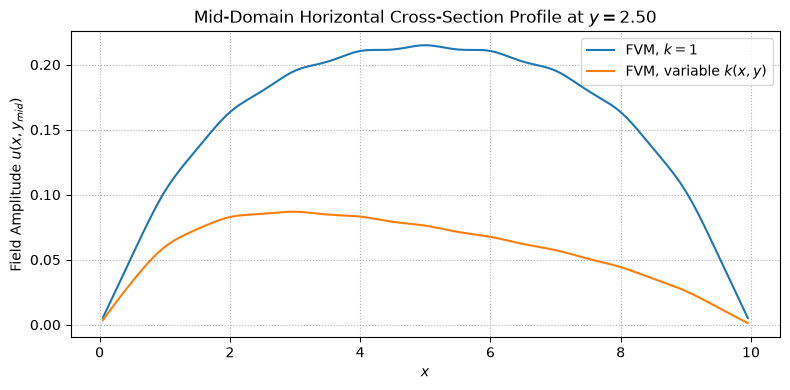

In [ ]:
plt.figure(figsize=(8, 4))

mid_y = (Ny - 1) // 2

plt.plot(x[:, mid_y], u_fvm_k1[:, mid_y], label='FVM, $k=1$')
plt.plot(x[:, mid_y], u_fvm_k2[:, mid_y], label='FVM, variable $k(x,y)$')

plt.title(f'Mid-Domain Horizontal Cross-Section Profile at $y = {Ly/2:.2f}$', fontsize=12)
plt.xlabel('$x$')
plt.ylabel('Field Amplitude $u(x, y_{mid})$')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

### 5.1 Maximum Principle

For the constant coefficient case, the governing equation is

$$
-\Delta u = f,
$$

with $f(x,y) \geq 0$ and homogeneous Dirichlet boundary conditions

$$
u = 0
\qquad \text{on } \partial\Omega.
$$

Since $-\Delta u = f \geq 0,$ it follows that $\Delta u \leq 0,$ meaning that the solution is superharmonic. According to the minimum principle, a non-constant superharmonic function attains its minimum value on the boundary of the domain. Because the boundary values are prescribed to be zero,

$$
\min_{\overline{\Omega}} u
=
\min_{\partial\Omega} u
=
0.
$$

Therefore,

$$
u(x,y) \geq 0
\qquad \text{in } \Omega.
$$

Hence the solution is expected to remain non-negative throughout the domain, increasing above zero in the interior due to the positive source terms and returning to zero at the boundary. This behaviour is also preserved by the numerical FDM and FVM solutions, since their discrete system matrices are monotone, so a non-negative source vector results in a non-negative numerical solution.

### 5.2 Comparison of the FD and FV Solutions

For $k(x,y)=1,$ the finite-volume discretization reduces to the same five-point stencil as the finite-difference discretization. Both methods therefore approximate

$$
-\Delta u = f
$$

with the same relation

$$
\left(
\frac{2}{h_x^2}
+
\frac{2}{h_y^2}
\right)u_{i,j}
-
\frac{u_{i-1,j}+u_{i+1,j}}{h_x^2}
-
\frac{u_{i,j-1}+u_{i,j+1}}{h_y^2}
=
f_{i,j}.
$$

As a result, on the same uniform grid the FD and FV methods are expected to produce essentially identical solutions,

$$
u_{\mathrm{FD}} \approx u_{\mathrm{FV}}.
$$

The RMSE between both solutions should therefore be close to machine precision,

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
u_{\mathrm{FD},i}
-
u_{\mathrm{FV},i}
\right)^2
}
\approx 0.
$$

With floating-point rounding errors being the reason for a nonzero RMSE.


### 5.3 Behaviour at the Boundary

The problem is subject to homogeneous Dirichlet boundary conditions,

$$
u(x,y)=0,
\qquad
(x,y)\in\partial\Omega.
$$

Therefore, both the finite-difference and finite-volume solutions are equal to zero at all four boundaries of the rectangular domain,

$$
u(0,y)=u(L_x,y)=0,
$$

and

$$
u(x,0)=u(x,L_y)=0.
$$

The solution takes non-negative values in the interior of the domain while satisfying the prescribed zero values on the boundary. This behaviour agrees with the homogeneous Dirichlet boundary condition and the minimum principle.


### 5.4 Effect of the Inhomogeneous Diffusion Coefficient
For the spatially varying case, the diffusion coefficient is

$$
k(x,y)=1+0.1(x+y+xy).
$$

The governing equation then takes the form

$$
-\nabla\cdot\left(k(x,y)\nabla u\right)=f,
$$

with the corresponding diffusive flux

$$
\mathbf{q}=-k(x,y)\nabla u.
$$

This relation shows that the strength of diffusion depends directly on the local value of $k$. For the same gradient, a larger value of $k$ results in a larger diffusive flux. Since $k(x,y)$ grows as both $x$ and $y$ increase, diffusion becomes progressively stronger toward the upper-right region of the domain.

As a result, the quantity represented by $u$ is transported more effectively in regions where $k$ is large. Equivalently, for a comparable flux,

$$
|\nabla u|
=
\frac{|\mathbf{q}|}{k},
$$

so a larger diffusion coefficient requires a smaller gradient. The solution is therefore expected to become flatter in regions where $k$ is large. The resulting solution also loses the symmetry observed for the constant case $k=1$. This can be seen particularly clearly along the horizontal centreline,

$$
y=\frac{L_y}{2}=2.5.
$$

Along this line,

$$
k(x,2.5)
=
1+0.1(x+2.5+2.5x)
=
1.25+0.35x.
$$

Thus, $k$ increases linearly as one moves from left to right. Diffusion is therefore stronger toward increasing $x$, causing the solution profile to become flatter and generally lower in this region compared with the constant-$k$ case.